In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import joblib

from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
!pip install pytorch-tabnet imbalanced-learn category_encoders

In [19]:

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv to EnviroBirth PreBEnvBD Dataset-Driven Prediction (1).csv


In [20]:

df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (73000, 59)
Columns: Index(['Address', 'Latitude', 'Longitude', 'SO2', 'NO2', 'CO', 'O3', 'PM2.5',
       'PM10', 'CASEID', 'BIDX', 'Birth_Order', 'Multiple_Birth',
       'Preceding_Birth_Interval', 'Succeeding_Birth_Interval',
       'Gestational_Duration', 'Mother_Age', 'Education', 'Wealth_Index',
       'Drinking_Water_Source', 'Toilet_Type', 'Electricity', 'Cooking_Fuel',
       'Usual_Residents', 'Sleeping_Rooms', 'Place_of_Delivery',
       'Multiple_Birth.1', 'Child_Alive', 'Age_at_Death_Days',
       'Age_at_Death_Months', 'Gestation_Months', 'Pregnancy_Duration',
       'Birth_Size_Reported', 'Birth_Weight_Reported', 'Mother_Age.1',
       'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Delivery_Assistance',
       'Csection_Delivery', 'Iron_Supplement', 'BP_Checked', 'Urine_Test',
       'Blood_Test', 'Ultrasound', 'Weight_Measured', 'Height_Measured',
       'Stomach_Exam', 'Fetal_heartbeat', 'Blood_Pressure_Test',
       'Cooking_Location', 'Separate_Kitchen', 'Ha

,Address,Latitude,Longitude,SO2,NO2,CO,O3,PM2.5,PM10,CASEID,...,Blood_Pressure_Test,Cooking_Location,Separate_Kitchen,Has_Mosquito_Net,Number_Mosquito_Nets,Children_Using_Nets,Rainfall,Humidity,Temperature,Preterm
0,"Uttara, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.059,1.2,0.0525,57,73,0100 1 4,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78.0,20.1,0
1,"Jatrabari, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.058,1.2,0.0525,59,71,0100 11 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79.0,21.0,1
2,"Kuril Bishow Road, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,59,70,0102 3 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,82.0,20.1,0
3,"Mohakhali, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,58,70,0102 8 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,73.0,21.0,0
4,"Dhanmondi, Dhaka, Bangladesh)",23.820612,90.421011,0.03,0.051,1.2,0.0525,61,69,0104 4 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,67.0,20.3,0


In [21]:
env_features = ["SO2","NO2","CO","O3","PM2.5","PM10","Rainfall","Humidity","Temperature"]
maternal_features = ["Mother_Age","Mother_Height","Mother_Weight","Mother_BMI","Gestation_Months","Birth_Weight_Reported"]
household_features = ["Education","Wealth_Index","Drinking_Water_Source","Toilet_Type","Cooking_Fuel","Cooking_Location","Separate_Kitchen","Electricity","Has_Mosquito_Net"]
drop_cols = ["CASEID","BIDX","Address","Latitude","Longitude"]
features = env_features + maternal_features + household_features


In [22]:
selected = [c for c in (env_features + maternal_features + household_features) if c in df.columns]
print("Selected features (will use):", selected)
target = "Preterm"
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in df.columns")

Selected features (will use): ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Birth_Weight_Reported', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd

X = df[selected].copy()
y = df[target].copy()

if y.dtype == 'object' or y.dtype.name == 'category':
    tmp = y.astype(str).str.strip().str.lower()
    if set(tmp.unique()).issubset({'yes','no','y','n'}):
        y = tmp.map({'yes':1,'y':1,'no':0,'n':0})
    else:
        le_target = LabelEncoder()
        y = le_target.fit_transform(y.astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


numeric_feats = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_feats = [c for c in selected if c not in numeric_feats]

empty_numeric = [c for c in numeric_feats if X_train[c].isna().all()]
if empty_numeric:
    print("Dropping fully empty numeric columns:", empty_numeric)
    X_train = X_train.drop(columns=empty_numeric)
    X_test = X_test.drop(columns=empty_numeric)
    numeric_feats = [c for c in numeric_feats if c not in empty_numeric]


num_imputer = SimpleImputer(strategy='median')
X_train[numeric_feats] = num_imputer.fit_transform(X_train[numeric_feats])
X_test[numeric_feats] = num_imputer.transform(X_test[numeric_feats])


if categorical_feats:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[categorical_feats] = cat_imputer.fit_transform(X_train[categorical_feats])
    X_test[categorical_feats] = cat_imputer.transform(X_test[categorical_feats])

    for c in categorical_feats:
        X_train[c] = pd.Series(X_train[c]).astype('category').cat.codes
        X_test[c] = pd.Series(X_test[c]).astype('category').cat.codes
else:
    print("No categorical features detected.")

scaler = StandardScaler()
X_train[numeric_feats] = scaler.fit_transform(X_train[numeric_feats])
X_test[numeric_feats] = scaler.transform(X_test[numeric_feats])


cat_idxs = [X_train.columns.get_loc(c) for c in categorical_feats]
cat_dims = [X_train[c].nunique() for c in categorical_feats]

print("Categorical indices:", cat_idxs)
print("Categorical dimensions:", cat_dims)


X_train_final = X_train.values
X_test_final = X_test.values


Dropping fully empty numeric columns: ['Birth_Weight_Reported']
No categorical features detected.
Categorical indices: []
Categorical dimensions: []


In [24]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report
import torch



In [25]:
clf = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',
    verbose=10,
    seed=42
)


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [26]:
clf.fit(
    X_train=X_train_final, y_train=y_train,
    eval_set=[(X_train_final, y_train), (X_test_final, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)


epoch 0  | loss: 0.35284 | train_accuracy: 0.92243 | valid_accuracy: 0.9224  |  0:00:10s
epoch 10 | loss: 0.24722 | train_accuracy: 0.92238 | valid_accuracy: 0.9224  |  0:01:13s
epoch 20 | loss: 0.24516 | train_accuracy: 0.92238 | valid_accuracy: 0.9224  |  0:02:00s
epoch 30 | loss: 0.24495 | train_accuracy: 0.92236 | valid_accuracy: 0.9224  |  0:03:06s
epoch 40 | loss: 0.24383 | train_accuracy: 0.92241 | valid_accuracy: 0.92247 |  0:03:52s
epoch 50 | loss: 0.24317 | train_accuracy: 0.92248 | valid_accuracy: 0.92288 |  0:04:38s
epoch 60 | loss: 0.24311 | train_accuracy: 0.92236 | valid_accuracy: 0.9224  |  0:05:26s
epoch 70 | loss: 0.24223 | train_accuracy: 0.92238 | valid_accuracy: 0.92288 |  0:06:12s

Early stopping occurred at epoch 70 with best_epoch = 50 and best_valid_accuracy = 0.92288


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:

print(type(clf.history))

history_dict = clf.history.history

print(type(history_dict))
print(history_dict.keys())

import pandas as pd
history_df = pd.DataFrame(history_dict)

print(history_df.head())



<class 'pytorch_tabnet.callbacks.History'>
<class 'dict'>
dict_keys(['loss', 'lr', 'train_accuracy', 'valid_accuracy'])
       loss    lr  train_accuracy  valid_accuracy
0  0.352840  0.02        0.922432        0.922397
1  0.261897  0.02        0.922380        0.922397
2  0.257067  0.02        0.922380        0.922397
3  0.253701  0.02        0.922380        0.922397
4  0.253017  0.02        0.922380        0.922397


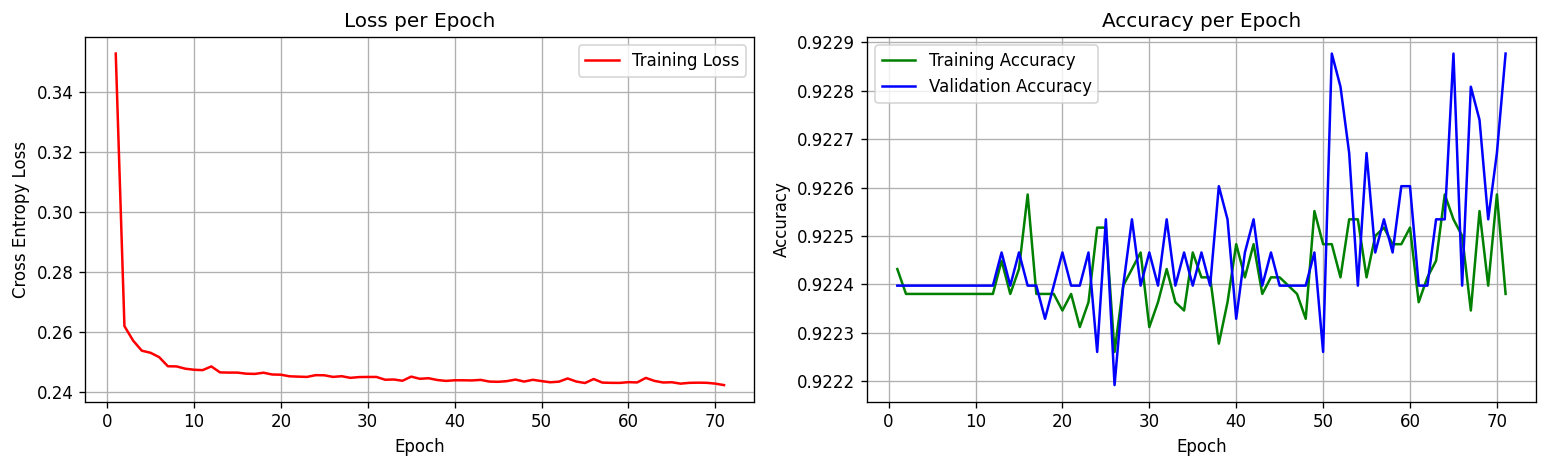

In [29]:
import matplotlib.pyplot as plt

def plot_training_curves(history_df, savepath='/content/drive/MyDrive/TabNet_LossVsAccuracy.pdf'):
    plt.figure(figsize=(13, 4), dpi=120)


    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(history_df)+1), history_df['loss'], label='Training Loss', color='red')

    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy Loss')
    plt.title('Loss per Epoch')
    plt.grid(True)
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history_df)+1), history_df['train_accuracy'], label='Training Accuracy', color='green')
    plt.plot(range(1, len(history_df)+1), history_df['valid_accuracy'], label='Validation Accuracy', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy per Epoch')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(savepath, bbox_inches='tight')
    plt.show()


plot_training_curves(history_df)


                  Feature    Importance
13       Gestation_Months  3.653342e-01
1                     NO2  1.777009e-01
19       Cooking_Location  1.429927e-01
3                      O3  7.996125e-02
12             Mother_BMI  7.315253e-02
17            Toilet_Type  3.620463e-02
7                Humidity  3.276140e-02
9              Mother_Age  3.114051e-02
15           Wealth_Index  2.249563e-02
20       Separate_Kitchen  2.208747e-02
4                   PM2.5  5.695246e-03
0                     SO2  5.295966e-03
5                    PM10  2.167286e-03
22       Has_Mosquito_Net  1.142604e-03
11          Mother_Weight  6.859779e-04
21            Electricity  6.804223e-04
16  Drinking_Water_Source  3.748487e-04
2                      CO  9.787413e-05
18           Cooking_Fuel  2.040036e-05
14              Education  5.919362e-06
8             Temperature  1.927189e-06
10          Mother_Height  2.952851e-07
6                Rainfall  0.000000e+00


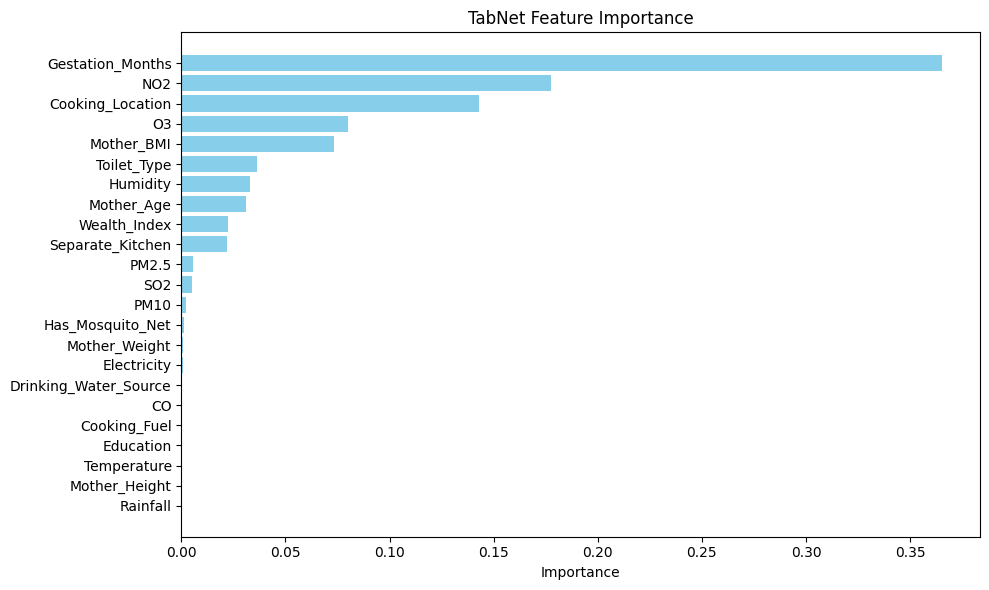

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = clf.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)


print(feature_df)

feature_df.to_csv('/content/drive/MyDrive/TabNet_FeatureImportance.csv', index=False)

plt.figure(figsize=(10,6))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('TabNet Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TabNet_FeatureImportance.pdf', bbox_inches='tight')
plt.show()


Accuracy: 0.9228767123287671
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     13467
           1       0.63      0.02      0.03      1133

    accuracy                           0.92     14600
   macro avg       0.78      0.51      0.49     14600
weighted avg       0.90      0.92      0.89     14600

Confusion Matrix:
 [[13457    10]
 [ 1116    17]]


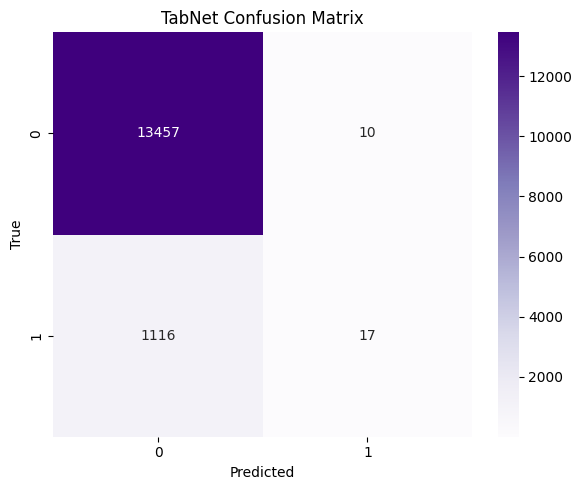

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = clf.predict(X_test_final)
y_true = y_test

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)
print(classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TabNet Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/TabNet_ConfusionMatrix.pdf")
plt.show()


In [35]:
# Add these imports at the top of your notebook (in the first code cell)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, matthews_corrcoef, log_loss
import numpy as np

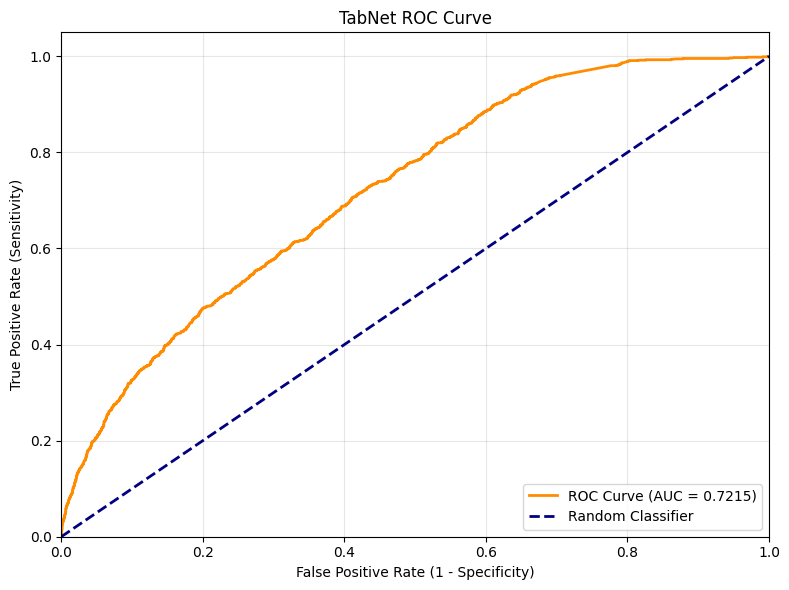

ROC-AUC Score: 0.7215


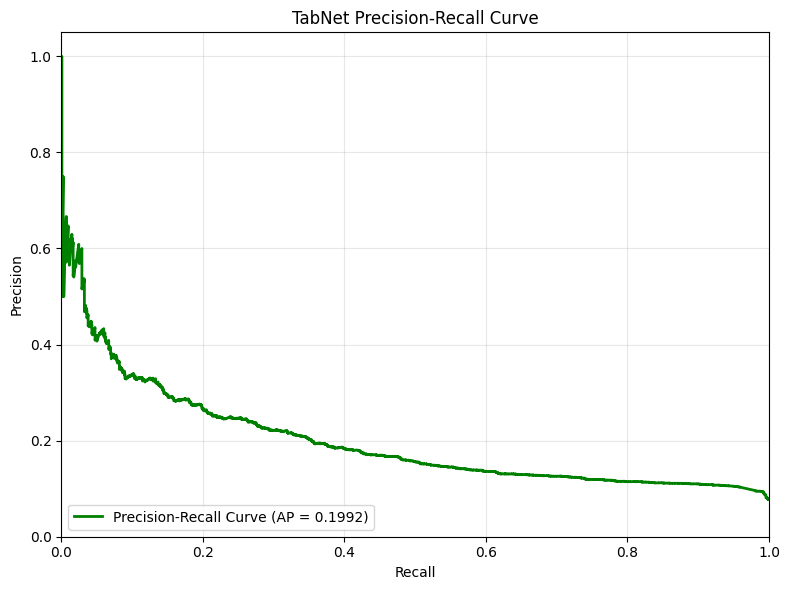

Average Precision Score: 0.1992
Log Loss (Cross-Entropy Loss): 0.246485
Matthews Correlation Coefficient (MCC): 0.088812

COMPREHENSIVE MODEL EVALUATION SUMMARY
Accuracy:                    0.922877
ROC-AUC:                     0.721504
Average Precision:           0.199220
Log Loss:                    0.246485
MCC:                         0.088812


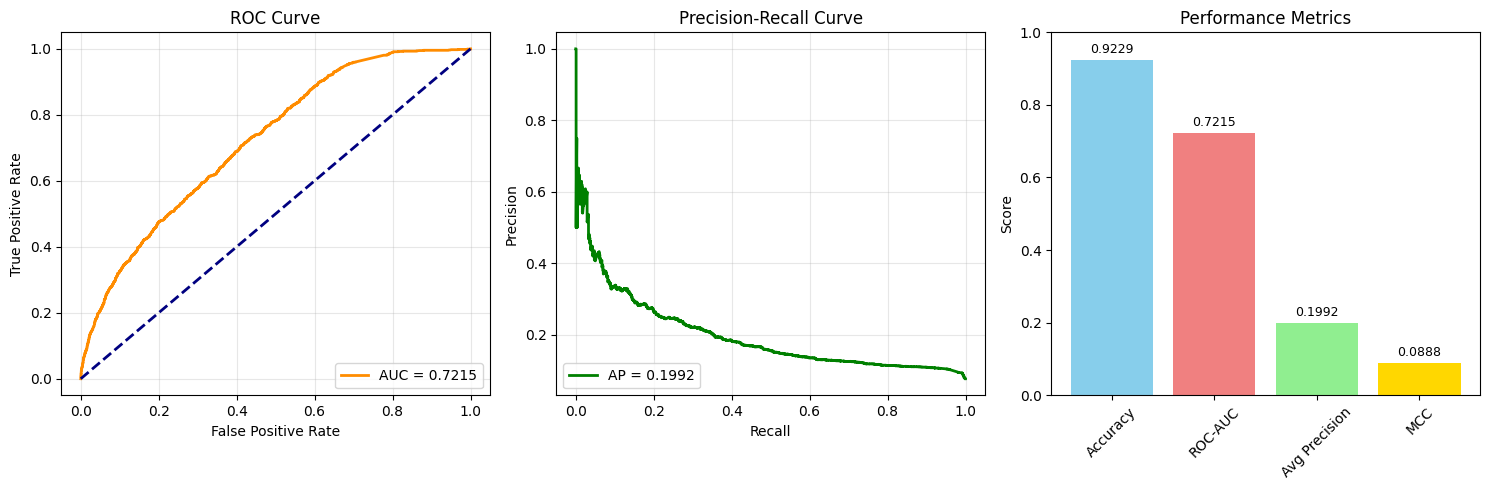


All additional curves and metrics have been saved to /content/drive/MyDrive/


In [36]:
# ========== ADDITIONAL EVALUATION METRICS AND CURVES ==========

# Get predicted probabilities for ROC and Precision-Recall curves
y_pred_proba = clf.predict_proba(X_test_final)[:, 1]  # Probability of class 1 (Preterm)

# 1. ROC CURVE
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('TabNet ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TabNet_ROC_Curve.pdf', bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

# 2. PRECISION-RECALL CURVE
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_proba)
average_precision = average_precision_score(y_true, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'Precision-Recall Curve (AP = {average_precision:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('TabNet Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TabNet_PrecisionRecall_Curve.pdf', bbox_inches='tight')
plt.show()

print(f"Average Precision Score: {average_precision:.4f}")

# 3. LOG LOSS (Cross-Entropy Loss)
log_loss_value = log_loss(y_true, y_pred_proba)
print(f"Log Loss (Cross-Entropy Loss): {log_loss_value:.6f}")

# 4. MATTHEWS CORRELATION COEFFICIENT (MCC)
mcc = matthews_corrcoef(y_true, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.6f}")

# 5. COMPREHENSIVE RESULTS SUMMARY
print("\n" + "="*50)
print("COMPREHENSIVE MODEL EVALUATION SUMMARY")
print("="*50)
print(f"Accuracy:                    {acc:.6f}")
print(f"ROC-AUC:                     {roc_auc:.6f}")
print(f"Average Precision:           {average_precision:.6f}")
print(f"Log Loss:                    {log_loss_value:.6f}")
print(f"MCC:                         {mcc:.6f}")
print("="*50)

# Optional: Plot all metrics together in a summary figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, color='green', lw=2, label=f'AP = {average_precision:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

# Metrics Bar Chart
metrics_names = ['Accuracy', 'ROC-AUC', 'Avg Precision', 'MCC']
metrics_values = [acc, roc_auc, average_precision, mcc]
colors_bar = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
axes[2].bar(metrics_names, metrics_values, color=colors_bar)
axes[2].set_ylim([0, 1])
axes[2].set_ylabel('Score')
axes[2].set_title('Performance Metrics')
axes[2].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(metrics_values):
    axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TabNet_Summary_Metrics.pdf', bbox_inches='tight')
plt.show()

print("\nAll additional curves and metrics have been saved to /content/drive/MyDrive/")